In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import keras
from keras import Model, Input ## functional API

from keras.layers import (### dense neural network
                                    Dense, Flatten,

                                    ### convolutionnal neural network
                                    Reshape, Convolution2D, MaxPooling2D, AveragePooling2D,Resizing,

                                    ### data augmentation
                                    Rescaling, Dropout, RandomRotation, RandomFlip,
                                    
                                    ### parallel sub-models, use functionnal API
                                    Concatenate,

                                    ### inverse convolution for auto encoder
                                    Convolution2DTranspose, UpSampling2D,
                                    )
                

from keras.datasets import mnist,fashion_mnist

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
def plot_lc(history: dict, metrics: list = ['loss', 'accuracy']) -> None:
    plt.figure(figsize=(20, 8))
    for i, metric in enumerate(metrics):
        plt.subplot(1, 2, i+1)
        plt.title(f'Learning curve for {metric}\n')
        plt.plot(history[metric], label='train')
        plt.plot(history[f'val_{metric}'], label='val')
        plt.xlabel('epochs')
        plt.ylabel(metric)
        plt.legend()
        if metric == 'accuracy':
            plt.ylim(0,1.1)
    plt.show()




def plot_cm_display(y_true: np.array, y_pred: np.array) -> None:
    cm = confusion_matrix(y_true, y_pred)
    
    #plt.figure(figsize=(20, 8))
    #plt.title('Confusion Matrix\n')
    CM = ConfusionMatrixDisplay(cm)
    CM.plot()
    #sns.heatmap(cm, cmap='vlag', annot=True, fmt='d', cbar=False)
    #plt.xlabel('y_pred')
    #plt.ylabel('y_true')
    plt.show()

from itertools import chain, cycle
def plot_ae_results(n_samples: int, x_test: np.ndarray, y_test: np.ndarray, y_pred: np.ndarray):
    samples = chain.from_iterable([(x_test[idx], y_test[idx], y_pred[idx]) for idx in np.random.randint(0, x_test.shape[0], n_samples)])
    plt.figure(figsize=(15, 10))
    for i, (img, title) in enumerate(zip(samples, cycle(('Noised', 'Original', 'Denoised',)))):
        plt.subplot(n_samples, 3, i+1)
        plt.title(title, fontdict={'fontsize': 12})
        plt.imshow(img, cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Data

In [3]:
def add_noise(X,noise_factor=0.05):

    SHAPE = X.shape

    ### garder les valeurs entre min et max originale
    X_noise = np.clip(a_max=np.max(X,axis=None),
                      a_min=np.min(X,axis=None),
                      a=X + noise_factor * np.random.normal(0,np.max(X,axis=None),SHAPE), ## loi normale centrée reduite
                     ) 
    
    return X_noise

In [4]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
X_train = X_train/np.max(X_train,axis=None)
X_test = X_test/np.max(X_test,axis=None)

noise_factor=0.2
X_train_noise,X_test_noise = add_noise(X_train,noise_factor),add_noise(X_test,noise_factor)

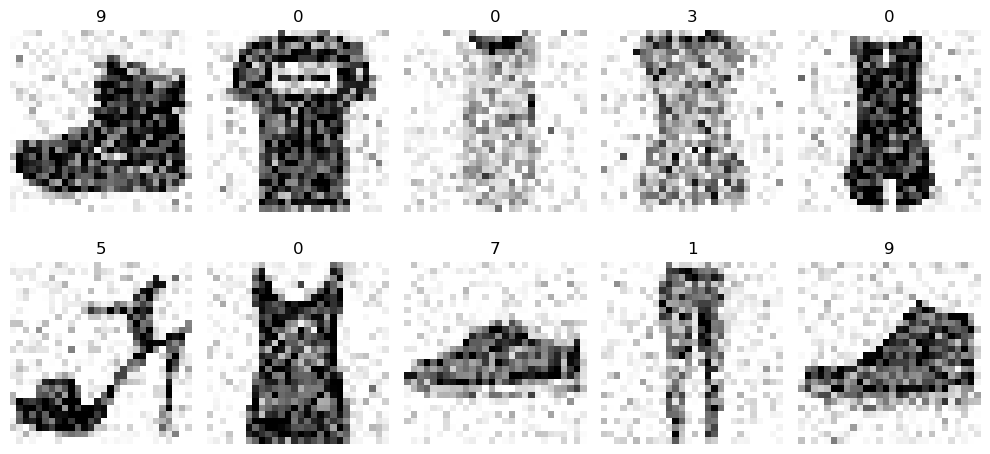

In [5]:
rdm_selection = np.random.randint(0,100,10)

plt.figure(figsize= (10,5) )
for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train_noise[i],cmap='Greys')
    plt.axis('off')
    plt.title(y_train[i])

    plt.subplot(2,5,6+i)
    plt.imshow(X_train_noise[rdm_selection[5+i]],cmap='Greys')
    plt.axis('off')
    plt.title(y_train[rdm_selection[5+i]])

plt.tight_layout()
plt.show()

In [36]:
def my_ae(input_shape,latent_space=256,activation='relu')->Model:

    inputs = Input(input_shape)
    ### preprocessing: 
    
    x = Reshape(target_shape=(28,28,1))(inputs) ### ajouter channel de couleur/filtres de convolution
    x = Resizing(height=32,width=32)(x) ### agrandir image pour avoir puissance de 2
    ### ---------------------------------------------- ###
    
    ### START ENCODER: CNN-like
    ### shape = (... , 32,32,1)
    x = Convolution2D(filters=16, kernel_size=7, strides=1, activation=activation, padding='same')(x)
    x = Convolution2D(filters=16, kernel_size=5, strides=1, activation=activation, padding='same')(x)
    ### shape = (... , 32,32,16)
    x = MaxPooling2D(2)(x)
    ### shape (..., 16, 16,16)
    
    x = Convolution2D(filters=16, kernel_size=5, strides=1, activation=activation, padding='same')(x)
    x = MaxPooling2D(2)(x)
    ### shape (..., 8,8, 16)
    
    x = Flatten()(x)
    ### shape (..., 8*8*16) ## 1024
    x = Dense(units=256, activation=activation)(x)
    ### END ENCODER
    
    ### ---------------------------------------------- ###
    
    ### START LATENT SPACE
    z = Dense(units= latent_space, activation=activation, name='latent_space')(x)

    ### END LATENT SPACE
    
    ### ---------------------------------------------- ###
    
    ### START DECODER = inverse/mirroir encoder

    x = Dense(units=256,activation=activation)(z)
    
    x = Dense(units=8*8*16,activation=activation)(x)    ### |
    x = Reshape((8,8,16))(x)                            ### | =>   +- = inverse flatten
    ### shape(...,8,8,16)
    
    x = Convolution2D(filters=16, kernel_size=5, strides=1, padding='same', activation=activation)(x)
    x = UpSampling2D(2)(x) ### +- = inverse ...Pooling
    ### shape(...,16,16,16)

    x = Convolution2D(filters=16, kernel_size=5, strides=1, padding='same', activation=activation)(x)
    x = Convolution2D(filters=16, kernel_size=7, strides=1, padding='same', activation=activation)(x)
    x = UpSampling2D(2)(x)
    ### shape(...,32,32,16)

    x = Convolution2D(filters=1, kernel_size=5, strides=1, padding='same', activation=activation)(x)
    ### shape(...,32,32,1)

    ### END DECODER
    ### ---------------------------------------------- ###
    
    ### post-processing
    x = Resizing(height=28,width=28)(x)
    outputs= Reshape(target_shape=(28,28))(x)


    ### reuse latent space neurons, for classification
    z = Dense(units= latent_space, activation=activation)(z)
    z = Dropout(0.3)(z)
    z = Dense(units= latent_space, activation=activation)(z)
    z = Dropout(0.3)(z)
    z = Dense(units=10,activation="softmax")(z)
    

    model = Model(inputs=inputs, outputs={"ae":outputs,"clf":z})

    model.compile(
        optimizer=keras.optimizers.Adam(),
        loss = {"ae":"mse" ### MSE car regression
                ,"clf":"sparse_categorical_crossentropy"
               }
        ,metrics={"clf":"accuracy"}
    )
    return model
    

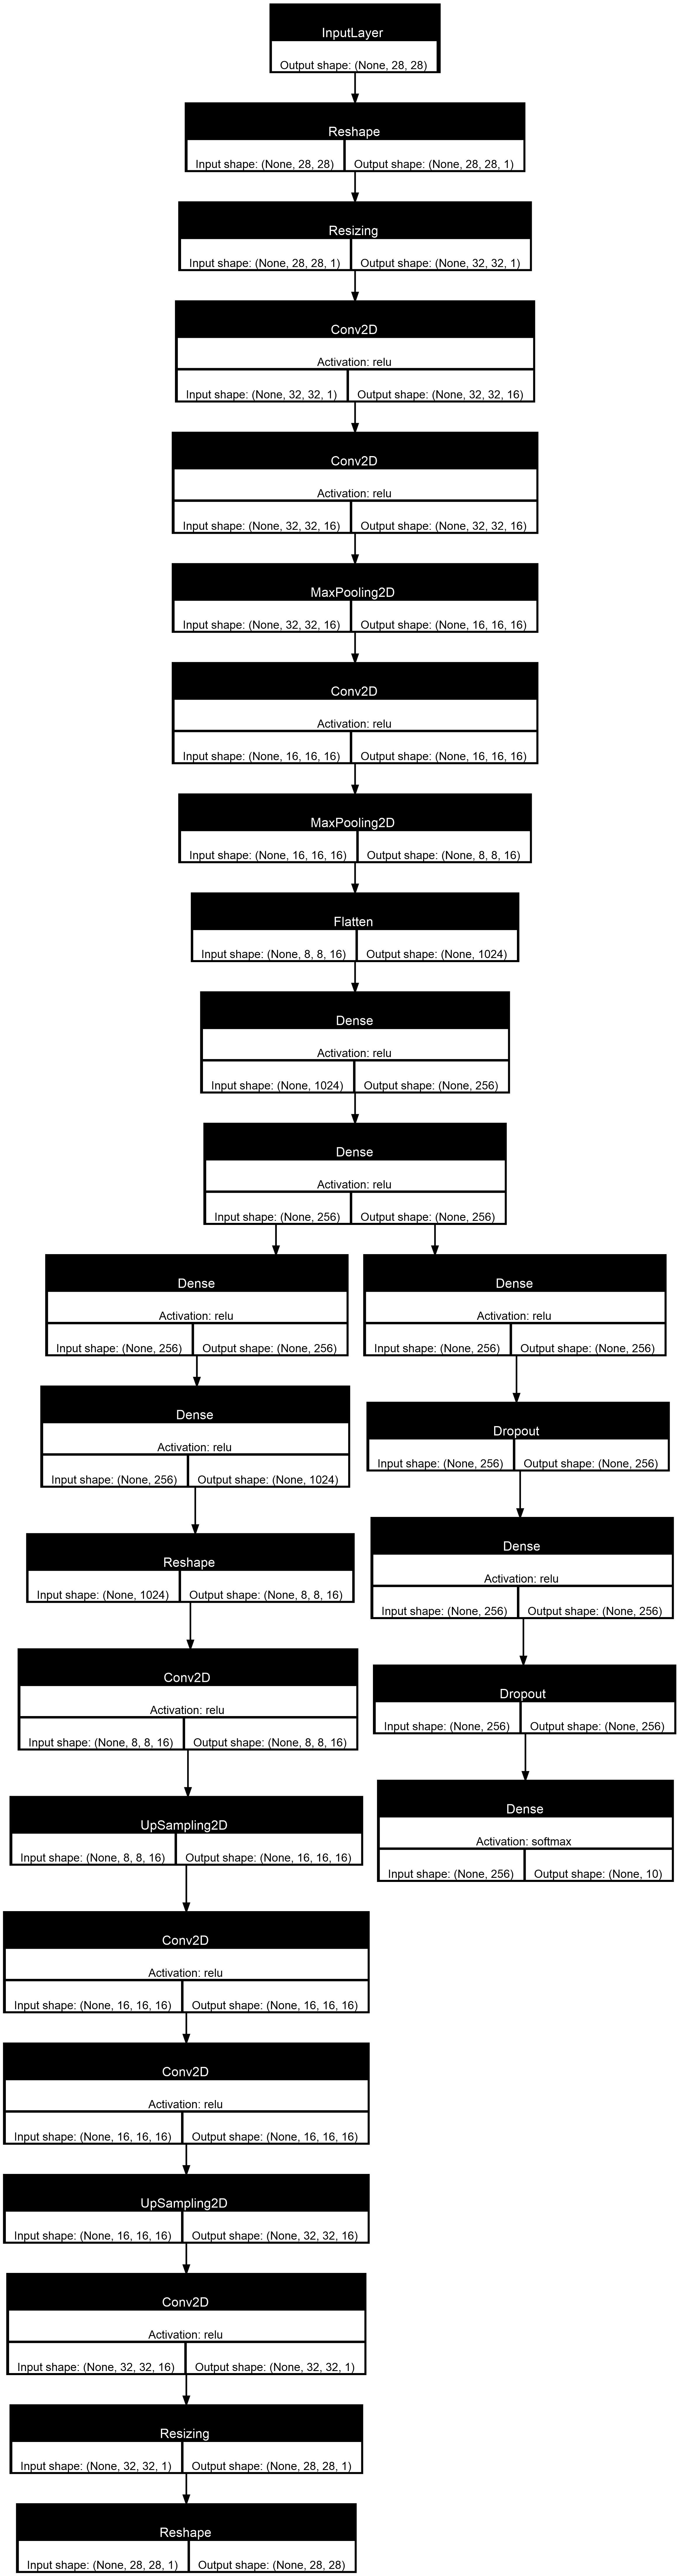

In [37]:
model = my_ae((28,28))

keras.utils.plot_model(
    model = model,
    show_layer_activations=True,
    show_shapes=True,
    expand_nested=True
)

In [38]:
model.fit(X_train_noise ## noised images
       , y= {"ae":X_train ## un noised/true images
             ,"clf":y_train
            }
       , batch_size=512, epochs=10, validation_split=.2)


Epoch 1/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 39s 349ms/step - ae_loss: 0.0731 - clf_accuracy: 0.6216 - clf_loss: 1.0192 - loss: 1.0937 - val_ae_loss: 0.0332 - val_clf_accuracy: 0.7833 - val_clf_loss: 0.5534 - val_loss: 0.5884
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 33s 349ms/step - ae_loss: 0.0308 - clf_accuracy: 0.8074 - clf_loss: 0.5191 - loss: 0.5500 - val_ae_loss: 0.0266 - val_clf_accuracy: 0.8367 - val_clf_loss: 0.4374 - val_loss: 0.4657
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 34s 356ms/step - ae_loss: 0.0265 - clf_accuracy: 0.8385 - clf_loss: 0.4433 - loss: 0.4698 - val_ae_loss: 0.0273 - val_clf_accuracy: 0.8477 - val_clf_loss: 0.4110 - val_loss: 0.4397
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 34s 358ms/step - ae_loss: 0.0246 - clf_accuracy: 0.8562 - clf_loss: 0.3956 - loss: 0.4203 - val_ae_loss: 0.0233 - val_clf_accuracy: 0.8591 - val_clf_loss: 0.3793 - val_loss: 0.4040
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 37s 398ms/step - ae_loss: 0.0231 - clf_accuracy: 0.8655 - clf_loss: 0.3655 - loss: 0.3

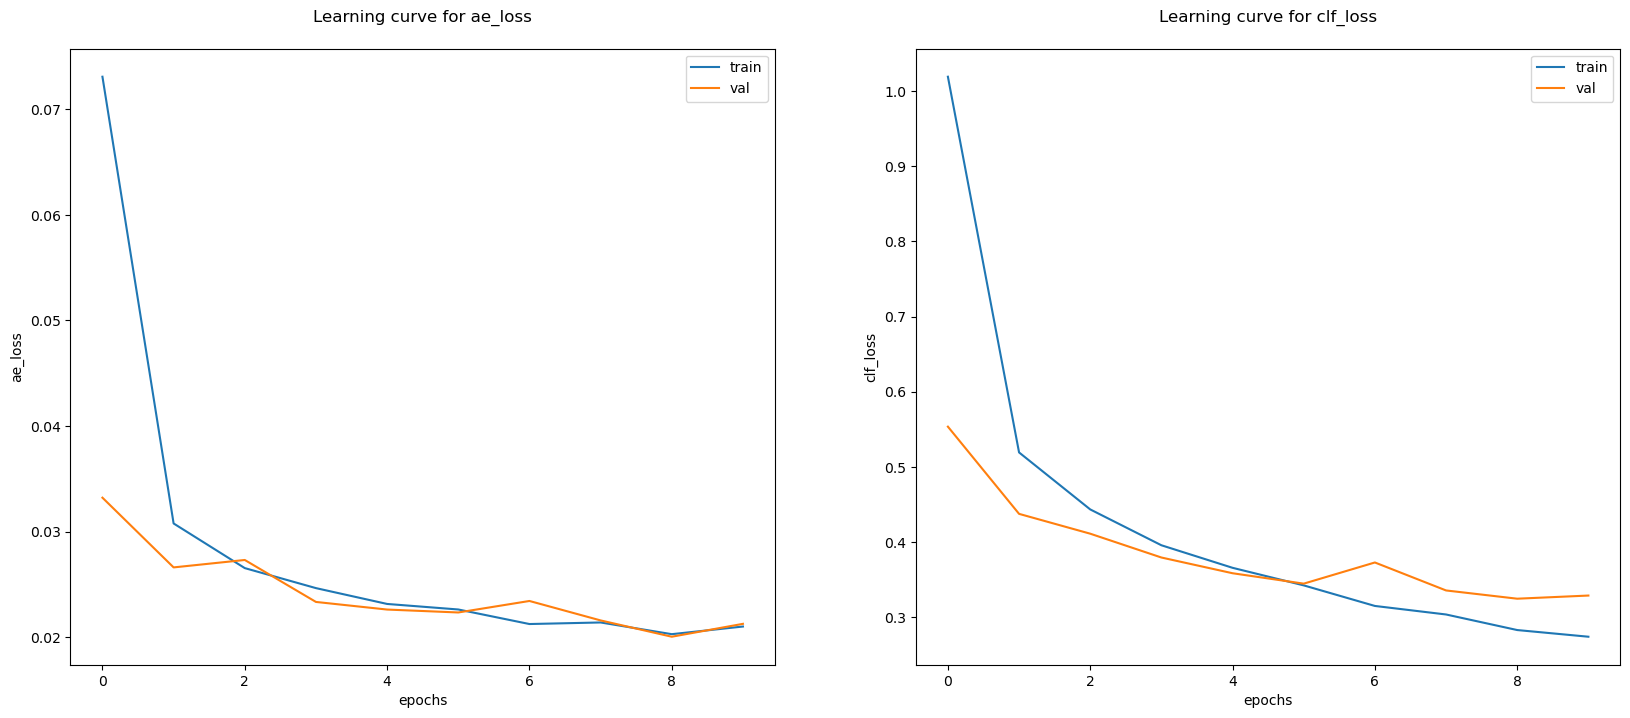

In [39]:
plot_lc(model.history.history,metrics=["ae_loss","clf_loss"])

In [40]:
model.history.history.keys()

dict_keys(['ae_loss', 'clf_accuracy', 'clf_loss', 'loss', 'val_ae_loss', 'val_clf_accuracy', 'val_clf_loss', 'val_loss'])

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step


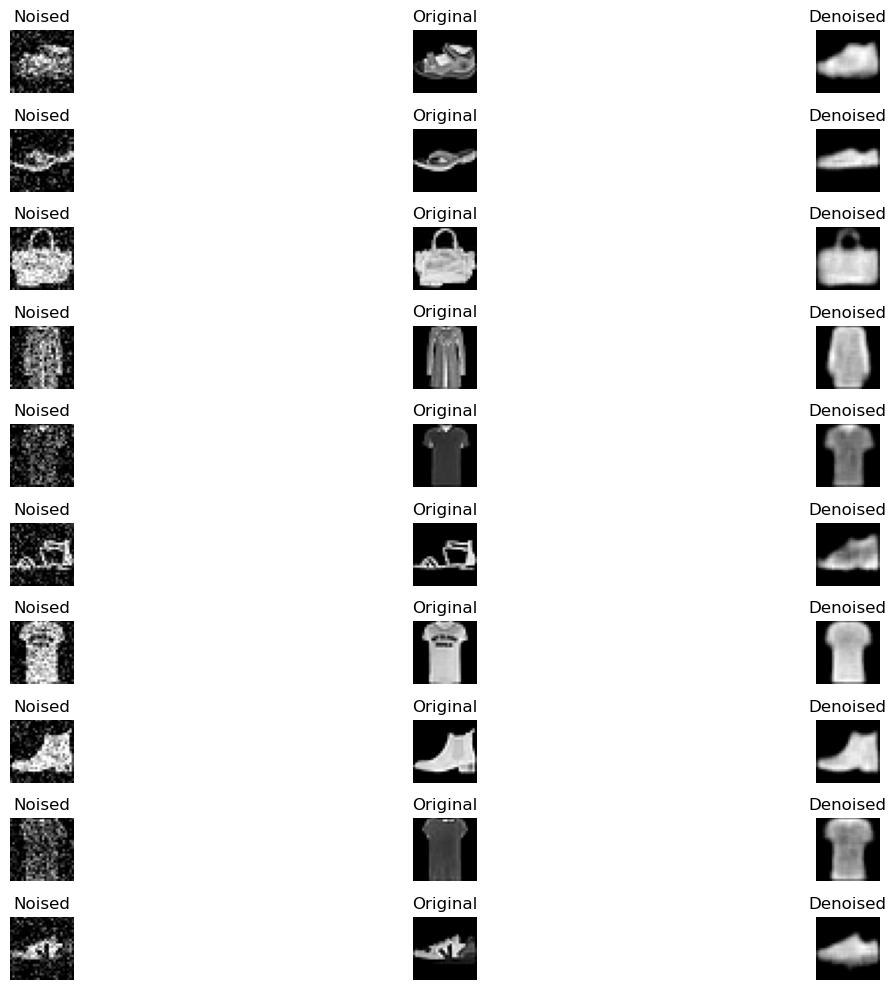

In [41]:
y_pred = model.predict(X_test_noise) ## noised images
plot_ae_results(10, X_test_noise, X_test, y_pred["ae"])

In [26]:
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)    │ (None, 28, 28)            │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ reshape_12 (Reshape)          │ (None, 28, 28, 1)         │               0 │ input_layer_4[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ resizing_8 (Resizing)         │ (None, 32, 32, 1)         │               0 │ reshape_12[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_28 (Conv2D)            │ (None, 32, 32, 16)        │             800 │ resizing_8[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_29 (Conv2D)            │ (None, 32, 32, 16)        │           6,416 │ conv2d_28[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_8               │ (None, 16, 16, 16)        │               0 │ conv2d_29[0][0]            │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_30 (Conv2D)            │ (None, 16, 16, 16)        │           6,416 │ max_pooling2d_8[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_9               │ (None, 8, 8, 16)          │               0 │ conv2d_30[0][0]            │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten_4 (Flatten)           │ (None, 1024)              │               0 │ max_pooling2d_9[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_22 (Dense)              │ (None, 256)               │         262,400 │ flatten_4[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ latent_space (Dense)          │ (None, 256)               │          65,792 │ dense_22[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_23 (Dense)              │ (None, 256)               │          65,792 │ latent_space[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_24 (Dense)              │ (None, 1024)              │         263,168 │ dense_23[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ reshape_13 (Reshape)          │ (None, 8, 8, 16)          │               0 │ dense_24[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_31 (Conv2D)            │ (None, 8, 8, 16)          │           6,416 │ reshape_13[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ up_sampling2d_8               │ (None, 16, 16, 16)        │               0 │ conv2d_31[0][0]            │
│ (UpSampling2D)                │                           │               

 Total params: 2,492,195 (9.51 MB)

 Trainable params: 830,731 (3.17 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,661,464 (6.34 MB)

In [42]:
(y_pred["clf"].argmax(axis=1)==y_test).mean() ### accuracy

np.float64(0.8735)

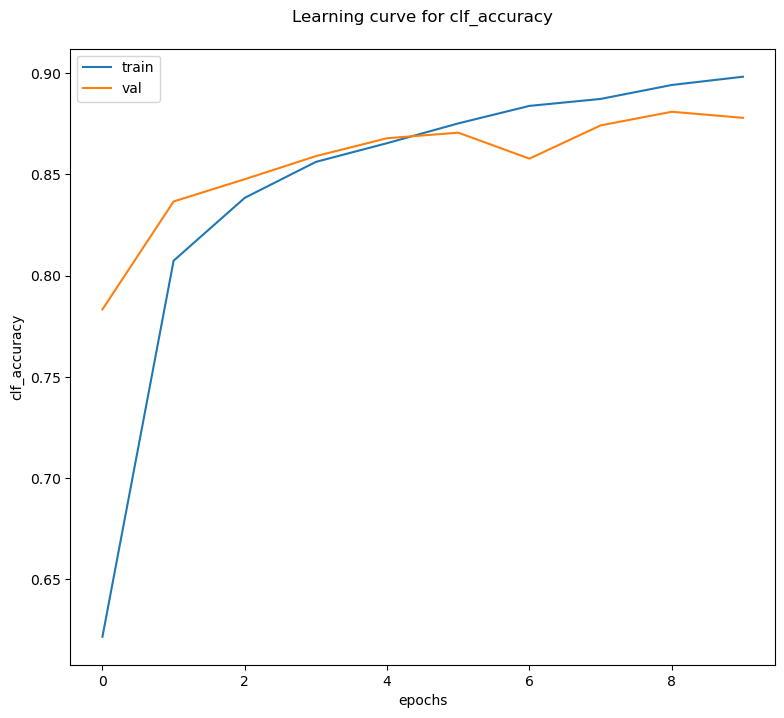

In [46]:

plot_lc(model.history.history,metrics=["clf_accuracy"])